In [2]:
import numpy as np

TrainMat = np.load('TrainDigits.npy')
TrainLab = np.load('TrainLabels.npy')

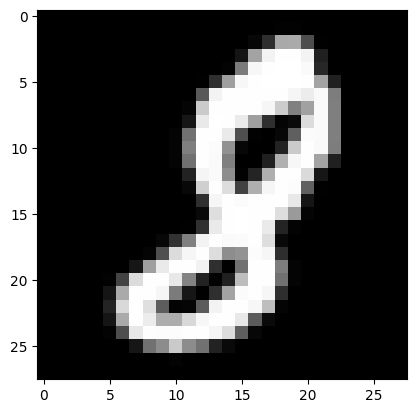

In [3]:
import matplotlib.pyplot as plt
TrainMat = np.load('TrainDigits.npy')
d = TrainMat[:,0]
D = np.reshape(d, (28,28)).T
plt.imshow(D, cmap = 'gray')

In [4]:
# Start Task 2
index_3 = (TrainLab == 3)
A3 = TrainMat[:,index_3[0]]
A3 = A3[:,0:400]
print('Number of threes: ', np.sum(index_3))

Number of threes:  24000


In [5]:
index_8 = (TrainLab == 8)
A8 = TrainMat[:,index_8[0]]
A8 = A8[:,0:400]
print('Number of eigths: ', np.sum(index_8))

Number of eigths:  24000


In [6]:
U3, S3, Vt3 = np.linalg.svd(A3, full_matrices= False)
U8, S8, Vt8 = np.linalg.svd(A8, full_matrices= False)

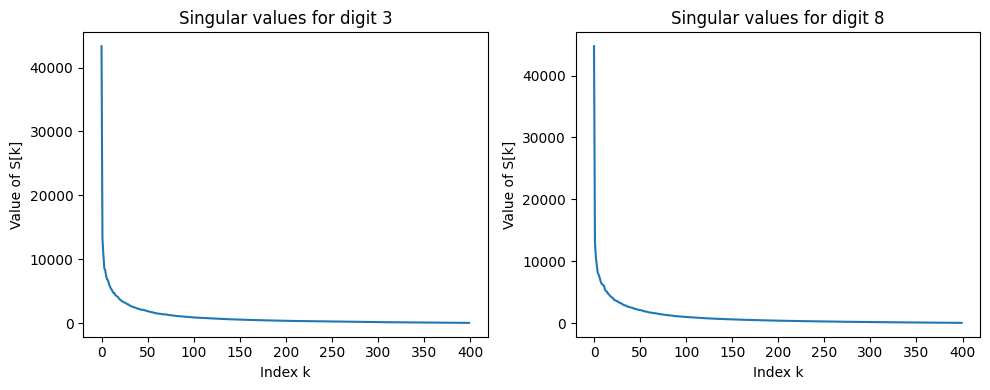

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(S3)
plt.title('Singular values for digit 3')
plt.xlabel('Index k')
plt.ylabel('Value of S[k]')

plt.subplot(1, 2, 2)
plt.plot(S8)
plt.title('Singular values for digit 8')
plt.xlabel('Index k')
plt.ylabel('Value of S[k]')

plt.tight_layout()
plt.show()

<Figure size 900x300 with 0 Axes>

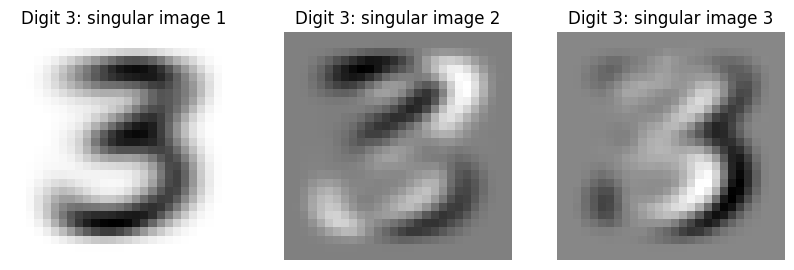

In [8]:
plt.figure(figsize=(9, 3))
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in range(3):
    
    d = U3[:,i]
    D = np.reshape(d, (28,28)).T
    
    axes[i].imshow(D, cmap = 'gray')
    axes[i].axis('off')
    axes[i].set_title(f"Digit 3: singular image {i+1}")
 
plt.show()

<Figure size 900x300 with 0 Axes>

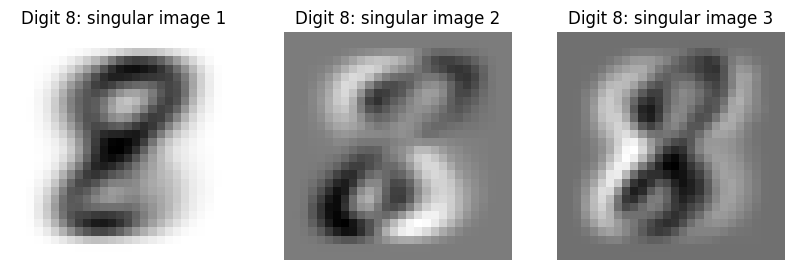

In [9]:
plt.figure(figsize=(9, 3))
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in range(3):
    
    d = U8[:,i]
    D = np.reshape(d, (28,28)).T
    
    axes[i].imshow(D, cmap = 'gray')
    axes[i].axis('off')
    axes[i].set_title(f"Digit 8: singular image {i+1}")
 
plt.show()

In [10]:
# Task 2 finished

In [ ]:
# Task 3 start

U_dict = {}
k_max = 15

for d in range(10):
    index = (TrainLab == d)
    Ad_all = TrainMat[:, index[0]]
    Ad = Ad_all[:, 0:400]
    U, S, Vt = np.linalg.svd(Ad, full_matrices = False)
    U_dict[d] = U[:, 0:k_max]

In [37]:
TestMat = np.load('TestDigits.npy')
TestLab = np.load('TestLabels.npy')

In [39]:
k_values = range(5, 16)
success_rates = {d: [] for d in range(10)}
test_labels_flat = TestLab[0] if len(TestLab.shape) > 1 else TestLab
num_test_images = TestMat.shape[1]

for k in k_values:
    residuals = np.zeros((10, num_test_images))
    for d in range(10):
        Uk = U_dict[d][:,0:k]
        approx = Uk @ (Uk.T @ TestMat)
        res_d = np.linalg.norm(TestMat - approx, axis = 0)
        residuals[d, :] = res_d
    predictions = np.argmin(residuals, axis = 0)

    for d in range(10):
        true_d_indices = (test_labels_flat == d)
        correct_guesses = np.sum(predictions[true_d_indices] == d)
        total_d_images = np.sum(true_d_indices)

        percentage = (correct_guesses / total_d_images) * 100
        success_rates[d].append(percentage)


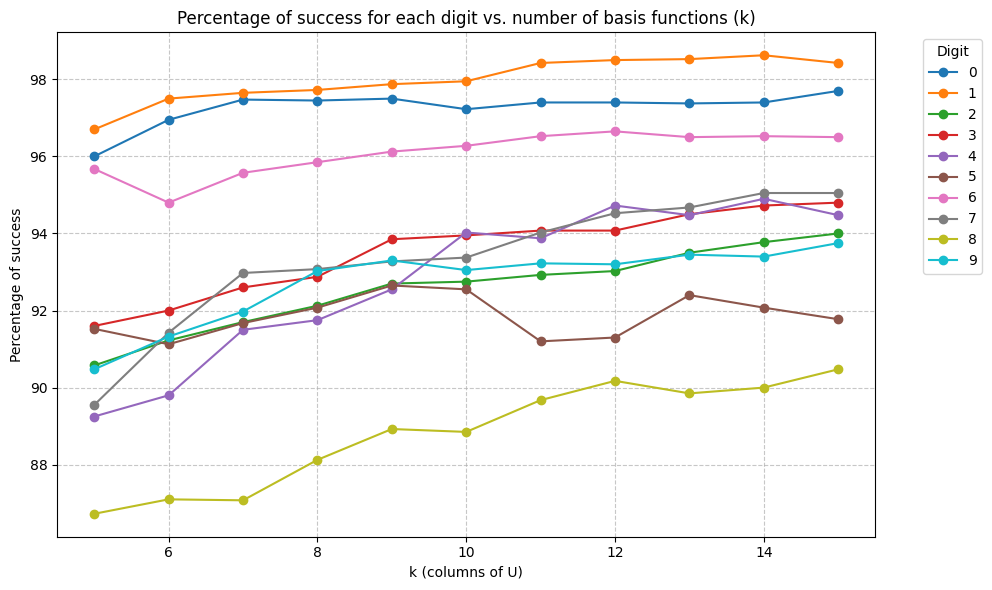

In [40]:
plt.figure(figsize=(10, 6))
k_values = list(range(5, 16))
for d in range(10):
    plt.plot(k_values, success_rates[d], marker='o', label=str(d))

plt.title('Percentage of success for each digit vs. number of basis functions (k)')
plt.xlabel('k (columns of U)')
plt.ylabel('Percentage of success')

plt.grid(True, linestyle='--', alpha =0.7)
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
import pandas as pd
k_values = list(range(5, 16))
df_success = pd.DataFrame(success_rates)

df_success.index = k_values
df_success.index.name = 'k'

df_success.columns = [f"Digit {d}" for d in range(10)]
df_success = df_success.round(2)

df_success

,Digit 0,Digit 1,Digit 2,Digit 3,Digit 4,Digit 5,Digit 6,Digit 7,Digit 8,Digit 9
k,,,,,,,,,,
5,96.00,96.70,90.58,91.60,89.25,91.52,95.68,89.55,86.72,90.48
6,96.95,97.50,91.22,92.00,89.80,91.12,94.80,91.42,87.10,91.32
7,97.48,97.65,91.70,92.60,91.50,91.68,95.58,92.98,87.08,91.98
8,97.45,97.72,92.12,92.88,91.75,92.07,95.85,93.08,88.12,93.02
9,97.50,97.88,92.70,93.85,92.55,92.65,96.12,93.28,88.92,93.30
10,97.22,97.95,92.75,93.95,94.02,92.55,96.28,93.38,88.85,93.05
11,97.40,98.42,92.92,94.08,93.88,91.20,96.52,94.02,89.68,93.22
12,97.40,98.50,93.02,94.08,94.72,91.30,96.65,94.52,90.18,93.20
13,97.38,98.52,93.50,94.50,94.48,92.40,96.50,94.68,89.85,93.45
